# Architecture C1 - Multi-Agent Always-L (Always Big)

This notebook runs Architecture C1, which is the "Always-Big" variant of Architecture C.

**Key difference from C (Adaptive)**:
- **C (Adaptive)**: Routes tasks to S/M/L developers based on story points
- **C1 (Always-L)**: Always uses Developer-L (strongest model) for all tasks

This enables comparison for **RQ3**: Can adaptive routing reduce cost while maintaining quality?

In [1]:
import os
import sys
import subprocess
import pathlib

REPO_URL = "https://github.com/LLM4SE-group-15/ArchitecturesForCodeDevelopmentWithLLMs.git"
REPO_DIR = pathlib.Path("/content/ArchitecturesForCodeDevelopmentWithLLMs")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-U", "pip"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)

print(f"Using repo at {REPO_DIR.resolve()}")

Cloning into '/content/ArchitecturesForCodeDevelopmentWithLLMs'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.4 requires fastcore<1.9,>=1.8.0, but you have fastcore 1.11.3 which is incompatible.


INFO: pip is looking at multiple versions of langchain-huggingface to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langgraph-prebuilt to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langgraph-prebuilt to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 14.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.4/536.4 k

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
fastai

In [2]:
!pip install -r requirements.txt

In [ ]:
import os
import getpass
from huggingface_hub import login

# Configurazione LangSmith
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "project_name"
os.environ["LANGCHAIN_API_KEY"] = "langchain_api_key"

# Forza sempre l'uso del token che inserisci
os.environ["HF_TOKEN"] = "hf_token"
login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)

os.environ["ARCHITECTURE"] = "C1"
print("ARCHITECTURE set to", os.environ["ARCHITECTURE"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


ARCHITECTURE set to C1


In [4]:
from huggingface_hub import HfApi

api = HfApi()
try:
    user_info = api.whoami(token=os.environ["HF_TOKEN"])
    print("Logged in to Hugging Face as:", user_info.get("name") or user_info.get("user"))
except Exception as exc:
    print("Login check failed:", exc)

Logged in to Hugging Face as: Riaburger


In [5]:
import json
import time
import logging
import pathlib
import os

from datetime import datetime

DEFAULT_ROOT = pathlib.Path("/content/ArchitecturesForCodeDevelopmentWithLLMs")
ROOT = DEFAULT_ROOT if DEFAULT_ROOT.exists() else pathlib.Path.cwd()

sys.path.insert(0, str(ROOT))

LOG_DIR = ROOT / "log"
LOG_DIR.mkdir(exist_ok=True)

logger = logging.getLogger("architecture_C1")
logger.setLevel(logging.INFO)
if logger.handlers:
    logger.handlers.clear()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
file_handler = logging.FileHandler(LOG_DIR / "architecture_C1.log")
stream_handler = logging.StreamHandler()
for handler in (file_handler, stream_handler):
    handler.setFormatter(formatter)
    logger.addHandler(handler)

logger.info("Logger ready. Repo root: %s", ROOT)
logger.info("Log files: %s", LOG_DIR)
print("Logs ->", LOG_DIR)

2026-01-28 13:55:18,258 | INFO | Logger ready. Repo root: /content/ArchitecturesForCodeDevelopmentWithLLMs
2026-01-28 13:55:18,259 | INFO | Log files: /content/ArchitecturesForCodeDevelopmentWithLLMs/log


Logs -> /content/ArchitecturesForCodeDevelopmentWithLLMs/log


In [6]:
import time
import json
import random
from src.data.task_loader import HumanEvalTaskLoader
from src.graph.graph import run_graph
from src.agents.llm import Architecture

ARCH = Architecture.C1
SEED_FIXED = 31

def run_humaneval_benchmark(limit: int = 15, shuffle: bool = True):
    """
    Run benchmark on HumanEval tasks.
    
    Args:
        limit: Number of tasks to run
        shuffle: If True, randomly sample tasks with fixed seed
    """
    loader = HumanEvalTaskLoader()
    all_tasks = loader.load_all()  # Load all 164 tasks
    
    if shuffle:
        random.seed(SEED_FIXED)
        tasks = random.sample(all_tasks, min(limit, len(all_tasks)))
    else:
        tasks = all_tasks[:limit]

    results = []
    total = len(tasks)
    logger.info("Loaded %s tasks from HumanEval (shuffle=%s, seed=%s)", total, shuffle, SEED_FIXED)
    print(f"Starting benchmark on {total} tasks...")
    
    for idx, task in enumerate(tasks, 1):
        logger.info("Running %s/%s %s", idx, total, task.task_id)
        print(f"[{idx}/{total}] Task {task.task_id} ({task.entry_point})... ", end="", flush=True)
        
        start = time.time()
        
        state = run_graph(
            task_id=task.task_id,
            task_description=task.prompt,
            test_code=task.test,
            entry_point=task.entry_point,
            architecture=ARCH,
        )

        elapsed = time.time() - start
        
        record = {
            "task_id": task.task_id,
            "entry_point": task.entry_point,
            "architecture": str(ARCH.value),
            "test_passed": state["test_passed"],
            "developer_tier": state.get("developer_tier"),
            "escalations": state["escalations"],
            "story_points_initial": state.get("story_points_initial"),
            "story_points_final": state.get("story_points_current"),
            "elapsed_seconds": elapsed,
            "generated_code": state.get("generated_code", ""),
        }
        results.append(record)
        
        logger.info(
            "Finished %s | pass=%s tier=%s escalations=%s elapsed=%.1fs",
            task.task_id,
            state["test_passed"],
            record["developer_tier"],
            record["escalations"],
            elapsed,
        )
        status_str = "PASS" if state["test_passed"] else "FAIL"
        print(f"{status_str} in {elapsed:.1f}s")

        with open(LOG_DIR / "architecture_C1.jsonl", "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
            
    return results

# Run: 15 random tasks (seed=31 for reproducibility)
sample_results = run_humaneval_benchmark(limit=164, shuffle=False)

# Summary
passed_count = sum(1 for r in sample_results if r['test_passed'])
print(f"\nBenchmark Completed. Passed: {passed_count}/{len(sample_results)}")

Loading HumanEval dataset...


Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

2026-01-28 13:55:23,531 | INFO | Loaded 164 tasks from HumanEval (shuffle=False, seed=31)
2026-01-28 13:55:23,532 | INFO | Running 1/164 HumanEval/0


Loaded 164 tasks.
Starting benchmark on 164 tasks...
[1/164] Task HumanEval/0 (has_close_elements)... 

2026-01-28 13:55:38,946 | INFO | Finished HumanEval/0 | pass=True tier=L escalations=0 elapsed=15.4s
2026-01-28 13:55:38,947 | INFO | Running 2/164 HumanEval/1


...

FAIL in 11.5s
[163/164] Task HumanEval/162 (string_to_md5)... 

2026-01-28 14:35:14,744 | INFO | Finished HumanEval/162 | pass=True tier=L escalations=0 elapsed=11.9s
2026-01-28 14:35:14,746 | INFO | Running 164/164 HumanEval/163


PASS in 11.9s
[164/164] Task HumanEval/163 (generate_integers)... 

2026-01-28 14:35:28,508 | INFO | Finished HumanEval/163 | pass=False tier=L escalations=0 elapsed=13.8s


FAIL in 13.8s

Benchmark Completed. Passed: 134/164


In [7]:
!cd log && cat architecture_C1.jsonl

{"task_id": "HumanEval/0", "entry_point": "has_close_elements", "architecture": "C1", "test_passed": true, "developer_tier": "L", "escalations": 0, "story_points_initial": 3, "story_points_final": 8, "elapsed_seconds": 15.413084506988525, "generated_code": "from typing import List\n\ndef has_close_elements(numbers: List[float], threshold: float) -> bool:\n    \"\"\"\n    Check if in the given list of numbers, any two numbers are closer to each other than the given threshold.\n    \n    Args:\n        numbers (List[float]): A list of floating-point numbers.\n        threshold (float): The threshold value to determine closeness between numbers.\n    \n    Returns:\n        bool: True if any two numbers are closer than the threshold, False otherwise.\n    \n    Examples:\n        >>> has_close_elements([1.0, 2.0, 3.0], 0.5)\n        False\n        >>> has_close_elements([1.0, 2.8, 3.0, 4.0, 5.0, 2.0], 0.3)\n        True\n    \"\"\"\n    if not numbers or len(numbers) < 2:\n        return 

## Evaluation Metrics for Architecture C1 (Always-L)

This section calculates the evaluation metrics as specified in `evaluation.md`:

- **Primary Metrics**: Pass Rate, Pass@1
- **Cost Metrics**: Execution Time, API Calls
- **C1 Specific**: Always uses tier L (no escalation expected)

In [8]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load results from JSONL file
log_file = LOG_DIR / "architecture_C1.jsonl"
results = []
if log_file.exists():
    with open(log_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                results.append(json.loads(line))
else:
    print(f"Warning: {log_file} not found. Make sure to run the tasks first.")

df = pd.DataFrame(results)
print(f"Loaded {len(df)} task results")

# Show all rows
pd.set_option('display.max_rows', None)
df

Loaded 164 task results


,task_id,entry_point,architecture,test_passed,developer_tier,escalations,story_points_initial,story_points_final,elapsed_seconds,generated_code
0,HumanEval/0,has_close_elements,C1,True,L,0,3,8,15.413085,from typing import List\n\ndef has_close_eleme...
1,HumanEval/1,separate_paren_groups,C1,True,L,0,5,8,18.484288,from typing import List\n\ndef separate_paren_...
2,HumanEval/2,truncate_number,C1,True,L,0,2,8,12.934809,def truncate_number(number: float) -> float:\n...
3,HumanEval/3,below_zero,C1,True,L,0,3,8,11.651388,from typing import List\n\ndef below_zero(oper...
4,HumanEval/4,mean_absolute_deviation,C1,True,L,0,3,8,14.001322,from typing import List\n\ndef mean_absolute_d...
5,HumanEval/5,intersperse,C1,True,L,0,3,8,12.383522,from typing import List\n\ndef intersperse(num...
6,HumanEval/6,parse_nested_parens,C1,True,L,0,5,8,13.875399,from typing import List\n\ndef parse_nested_pa...
7,HumanEval/7,filter_by_substring,C1,True,L,0,2,8,15.728333,from typing import List\n\ndef filter_by_subst...
8,HumanEval/8,sum_product,C1,True,L,0,3,8,13.547094,"from typing import List, Tuple\nfrom functools..."
9,HumanEval/9,rolling_max,C1,False,L,0,3,8,13.729977,from typing import List\n\ndef rolling_max(num...


In [9]:
# Static Code Quality Metrics (Radon)
# Calculates Cyclomatic Complexity and Maintainability Index for generated code

from radon.complexity import cc_visit
from radon.metrics import mi_visit

def calculate_static_metrics(code: str) -> dict:
    """Calculate static code quality metrics using Radon."""
    if not code or not code.strip():
        return {
            "cyclomatic_complexity_avg": None, 
            "cyclomatic_complexity_max": None,
            "maintainability_index": None
        }
    
    try:
        # Cyclomatic Complexity - average across all functions
        cc_results = cc_visit(code)
        if cc_results:
            avg_cc = sum(block.complexity for block in cc_results) / len(cc_results)
            max_cc = max(block.complexity for block in cc_results)
        else:
            avg_cc = 1  # No functions = simple code
            max_cc = 1
    except Exception:
        avg_cc = None
        max_cc = None
    
    try:
        # Maintainability Index (0-100, higher is better)
        mi_score = mi_visit(code, multi=False)
    except Exception:
        mi_score = None
    
    return {
        "cyclomatic_complexity_avg": avg_cc,
        "cyclomatic_complexity_max": max_cc,
        "maintainability_index": mi_score
    }

# Calculate metrics for all generated code
print("\nCalculating static code quality metrics...")
static_metrics = []
for idx, row in df.iterrows():
    code = row.get("generated_code", "")
    metrics = calculate_static_metrics(code)
    metrics["task_id"] = row["task_id"]
    metrics["test_passed"] = row["test_passed"]
    static_metrics.append(metrics)

metrics_df = pd.DataFrame(static_metrics)

# Add to main dataframe
df["cyclomatic_complexity_avg"] = metrics_df["cyclomatic_complexity_avg"]
df["cyclomatic_complexity_max"] = metrics_df["cyclomatic_complexity_max"]
df["maintainability_index"] = metrics_df["maintainability_index"]

# Summary statistics
valid_cc = metrics_df["cyclomatic_complexity_avg"].dropna()
valid_mi = metrics_df["maintainability_index"].dropna()

print("\n" + "=" * 60)
print("STATIC CODE QUALITY METRICS")
print("=" * 60)
print(f"\nCyclomatic Complexity (lower is better):")
print(f"  Average CC: {valid_cc.mean():.2f}" if len(valid_cc) > 0 else "  Average CC: N/A")
print(f"  Median CC: {valid_cc.median():.2f}" if len(valid_cc) > 0 else "  Median CC: N/A")
print(f"  Max CC: {metrics_df['cyclomatic_complexity_max'].max():.2f}" if metrics_df['cyclomatic_complexity_max'].notna().any() else "  Max CC: N/A")
print(f"\nMaintainability Index (0-100, higher is better):")
print(f"  Average MI: {valid_mi.mean():.2f}" if len(valid_mi) > 0 else "  Average MI: N/A")
print(f"  Median MI: {valid_mi.median():.2f}" if len(valid_mi) > 0 else "  Median MI: N/A")
print(f"  Min MI: {valid_mi.min():.2f}" if len(valid_mi) > 0 else "  Min MI: N/A")
print("=" * 60)

# Passed vs Failed comparison
passed_df = metrics_df[metrics_df["test_passed"] == True]
failed_df = metrics_df[metrics_df["test_passed"] == False]

print(f"\nComparison - Passed vs Failed Tasks:")
print(f"  Passed tasks - Avg CC: {passed_df['cyclomatic_complexity_avg'].mean():.2f}, Avg MI: {passed_df['maintainability_index'].mean():.2f}" if len(passed_df) > 0 else "  Passed tasks: No data")
print(f"  Failed tasks - Avg CC: {failed_df['cyclomatic_complexity_avg'].mean():.2f}, Avg MI: {failed_df['maintainability_index'].mean():.2f}" if len(failed_df) > 0 else "  Failed tasks: No data")



Calculating static code quality metrics...

STATIC CODE QUALITY METRICS

Cyclomatic Complexity (lower is better):
  Average CC: 4.58
  Median CC: 4.00
  Max CC: 16.00

Maintainability Index (0-100, higher is better):
  Average MI: 81.06
  Median MI: 82.38
  Min MI: 48.94

Comparison - Passed vs Failed Tasks:
  Passed tasks - Avg CC: 4.55, Avg MI: 80.61
  Failed tasks - Avg CC: 4.85, Avg MI: 85.69


In [10]:
# Helper function for Wilson score confidence interval
def wilson_ci(successes, n, confidence=0.95):
    """Calculate Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0, 0, 0
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denominator = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n) / denominator
    return p_hat, center - margin, center + margin

# Calculate Pass Rate (after all retries)
total_tasks = len(df)
passed_tasks = df["test_passed"].sum()
pass_rate = passed_tasks / total_tasks if total_tasks > 0 else 0

# For C1: Pass@1 = Pass Rate (always uses L, no escalation needed)
# But we still calculate it properly for consistency
passed_first_attempt = df[(df["test_passed"] == True) & (df["escalations"] == 0)].shape[0]
pass_at_1 = passed_first_attempt / total_tasks if total_tasks > 0 else 0

# Calculate 95% Confidence Intervals
_, ci_low, ci_high = wilson_ci(passed_tasks, total_tasks)
_, ci_low_at1, ci_high_at1 = wilson_ci(passed_first_attempt, total_tasks)

print("=" * 60)
print("PRIMARY METRICS - Architecture C1 (Always-L)")
print("=" * 60)
print(f"\nDataset: HumanEval (164 total problems)")
print(f"Tasks Evaluated: {total_tasks}")
print(f"\nPass Rate (after retries): {pass_rate:.2%} ({passed_tasks}/{total_tasks})")
print(f"  95% CI: [{ci_low:.2%}, {ci_high:.2%}]")
print(f"\nPass@1 (first attempt): {pass_at_1:.2%} ({passed_first_attempt}/{total_tasks})")
print(f"  95% CI: [{ci_low_at1:.2%}, {ci_high_at1:.2%}]")
print(f"\nNote: C1 always uses Developer-L, so escalations should be 0.")
print("=" * 60)

PRIMARY METRICS - Architecture C1 (Always-L)

Dataset: HumanEval (164 total problems)
Tasks Evaluated: 164

Pass Rate (after retries): 81.71% (134/164)
  95% CI: [75.09%, 86.88%]

Pass@1 (first attempt): 81.71% (134/164)
  95% CI: [75.09%, 86.88%]

Note: C1 always uses Developer-L, so escalations should be 0.


In [11]:
# Calculate Cost Metrics
avg_time = df["elapsed_seconds"].mean()
std_time = df["elapsed_seconds"].std()
median_time = df["elapsed_seconds"].median()
total_time = df["elapsed_seconds"].sum()
min_time = df["elapsed_seconds"].min()
max_time = df["elapsed_seconds"].max()

# For C1: 3 API calls per task (Planner + Developer-L + Reviewer)
# No additional calls for escalation since we always use L
df["api_calls"] = 3 + (df["escalations"] * 2)
avg_api_calls = df["api_calls"].mean()
total_api_calls = df["api_calls"].sum()

print("\n" + "=" * 60)
print("COST METRICS")
print("=" * 60)
print(f"\nExecution Time Statistics:")
print(f"  Average Time per Task: {avg_time:.2f} seconds")
print(f"  Std Dev: {std_time:.2f} seconds")
print(f"  Median Time: {median_time:.2f} seconds")
print(f"  Min Time: {min_time:.2f} seconds")
print(f"  Max Time: {max_time:.2f} seconds")
print(f"  Total Execution Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print(f"\nAPI Calls:")
print(f"  Average API Calls per Task: {avg_api_calls:.2f}")
print(f"  Total API Calls: {total_api_calls}")
print("=" * 60)


COST METRICS

Execution Time Statistics:
  Average Time per Task: 14.66 seconds
  Std Dev: 3.11 seconds
  Median Time: 14.16 seconds
  Min Time: 8.60 seconds
  Max Time: 37.53 seconds
  Total Execution Time: 2404.58 seconds (40.08 minutes)

API Calls:
  Average API Calls per Task: 3.00
  Total API Calls: 492


In [12]:
# Developer Tier Distribution (should all be L for C1)
print("\n" + "=" * 60)
print("DEVELOPER TIER DISTRIBUTION")
print("=" * 60)

if "developer_tier" in df.columns:
    tier_counts = df["developer_tier"].value_counts()
    print("\n| Developer Tier | Count | Percentage |")
    print("|----------------|-------|------------|")
    for tier in ["S", "M", "L"]:
        if tier in tier_counts.index:
            count = tier_counts[tier]
            pct = 100 * count / total_tasks
            print(f"| {tier}              | {count:>5} | {pct:>10.2f}% |")
        else:
            print(f"| {tier}              |     0 |       0.00% |")

# Escalation check (should be 0 for C1)
print(f"\nTotal Escalations: {df['escalations'].sum()} (expected: 0 for C1)")
print("=" * 60)


DEVELOPER TIER DISTRIBUTION

| Developer Tier | Count | Percentage |
|----------------|-------|------------|
| S              |     0 |       0.00% |
| M              |     0 |       0.00% |
| L              |   164 |     100.00% |

Total Escalations: 0 (expected: 0 for C1)


In [13]:
# Per-Task Results
print("\n" + "=" * 60)
print("PER-TASK RESULTS")
print("=" * 60)
print("\n| Task ID           | Entry Point                  | Tier | Passed | Time (s) |")
print("|-------------------|------------------------------|------|--------|----------|")
for _, row in df.iterrows():
    status = "PASS" if row["test_passed"] else "FAIL"
    tier = row.get("developer_tier", "L")
    print(f"| {row['task_id']:<17} | {row['entry_point']:<28} | {tier:<4} | {status:<6} | {row['elapsed_seconds']:>8.2f} |")
print("=" * 60)


PER-TASK RESULTS

| Task ID           | Entry Point                  | Tier | Passed | Time (s) |
|-------------------|------------------------------|------|--------|----------|
| HumanEval/0       | has_close_elements           | L    | PASS   |    15.41 |
| HumanEval/1       | separate_paren_groups        | L    | PASS   |    18.48 |
| HumanEval/2       | truncate_number              | L    | PASS   |    12.93 |
| HumanEval/3       | below_zero                   | L    | PASS   |    11.65 |
| HumanEval/4       | mean_absolute_deviation      | L    | PASS   |    14.00 |
| HumanEval/5       | intersperse                  | L    | PASS   |    12.38 |
| HumanEval/6       | parse_nested_parens          | L    | PASS   |    13.88 |
| HumanEval/7       | filter_by_substring          | L    | PASS   |    15.73 |
| HumanEval/8       | sum_product                  | L    | PASS   |    13.55 |
| HumanEval/9       | rolling_max                  | L    | FAIL   |    13.73 |
| HumanEval/10      |

/tmp/ipykernel_24/3281081253.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=["Passed", "Failed"], patch_artist=True)


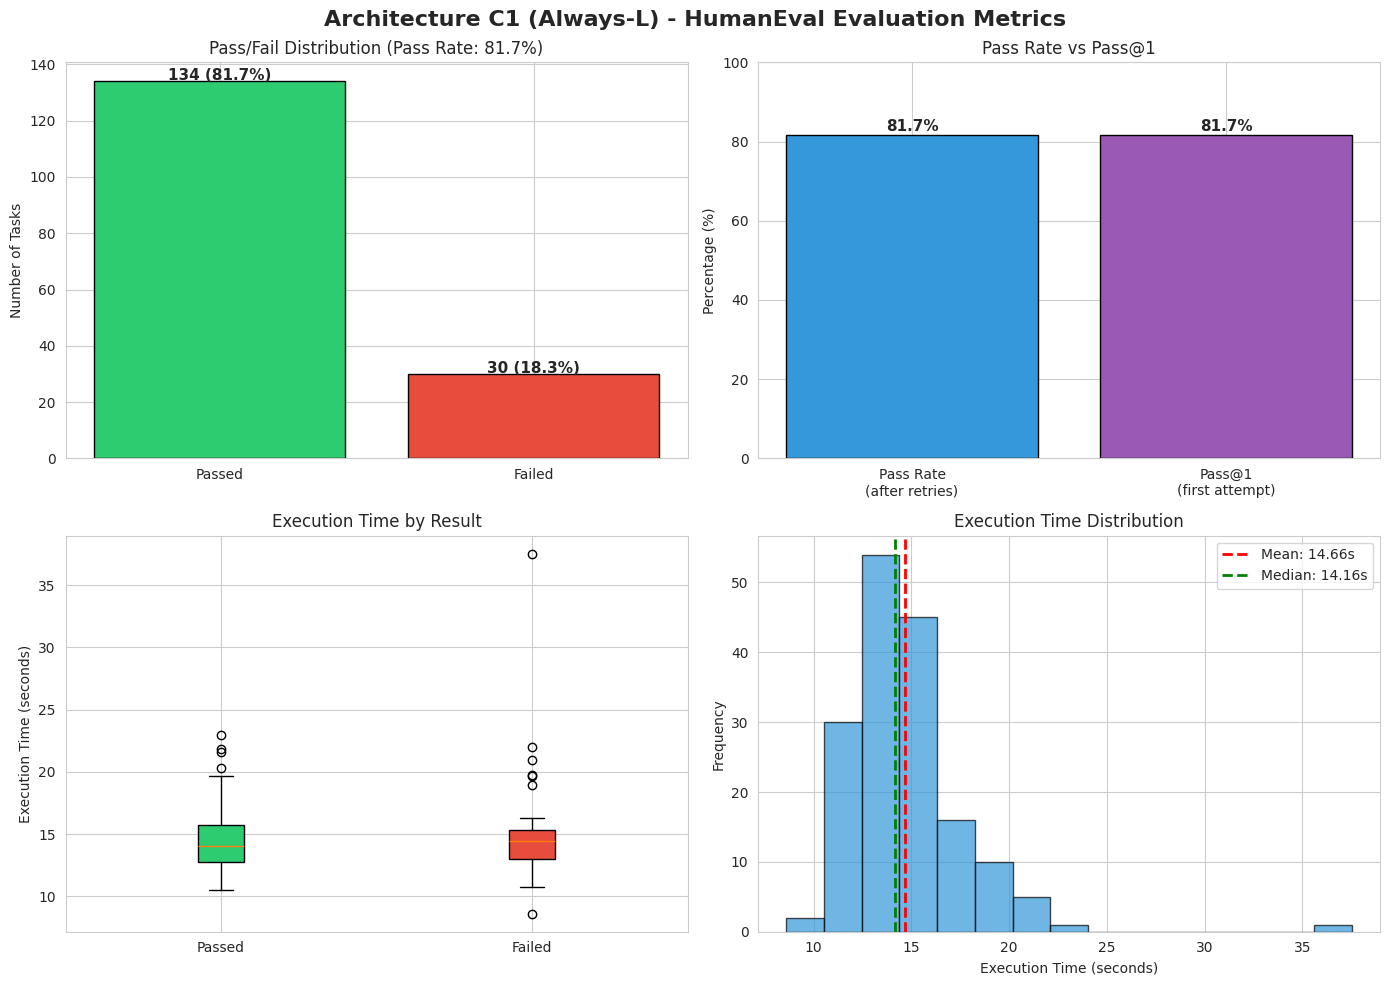


Visualization saved to: /content/ArchitecturesForCodeDevelopmentWithLLMs/log/architecture_C1_metrics.png


In [14]:
# Visualizations
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Architecture C1 (Always-L) - HumanEval Evaluation Metrics", fontsize=16, fontweight="bold")

# 1. Pass/Fail Bar Chart
ax1 = axes[0, 0]
categories = ["Passed", "Failed"]
counts = [passed_tasks, total_tasks - passed_tasks]
colors = ["#2ecc71", "#e74c3c"]
bars = ax1.bar(categories, counts, color=colors, edgecolor="black")
ax1.set_ylabel("Number of Tasks")
ax1.set_title(f"Pass/Fail Distribution (Pass Rate: {pass_rate:.1%})")
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f"{count} ({count/total_tasks:.1%})", ha="center", fontsize=11, fontweight="bold")

# 2. Pass Rate vs Pass@1 comparison
ax2 = axes[0, 1]
metrics = ["Pass Rate\n(after retries)", "Pass@1\n(first attempt)"]
values = [pass_rate * 100, pass_at_1 * 100]
colors_bar = ["#3498db", "#9b59b6"]
bars = ax2.bar(metrics, values, color=colors_bar, edgecolor="black")
ax2.set_ylabel("Percentage (%)")
ax2.set_title("Pass Rate vs Pass@1")
ax2.set_ylim(0, 100)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

# 3. Execution Time Box Plot (Passed vs Failed)
ax3 = axes[1, 0]
passed_times = df[df["test_passed"]]["elapsed_seconds"]
failed_times = df[~df["test_passed"]]["elapsed_seconds"]
if len(passed_times) > 0 and len(failed_times) > 0:
    box_data = [passed_times, failed_times]
    bp = ax3.boxplot(box_data, labels=["Passed", "Failed"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][1].set_facecolor("#e74c3c")
else:
    ax3.bar(["Passed", "Failed"], [passed_times.mean() if len(passed_times) > 0 else 0, 
                                    failed_times.mean() if len(failed_times) > 0 else 0],
            color=["#2ecc71", "#e74c3c"])
ax3.set_ylabel("Execution Time (seconds)")
ax3.set_title("Execution Time by Result")

# 4. Execution Time Histogram
ax4 = axes[1, 1]
ax4.hist(df["elapsed_seconds"], bins=15, edgecolor="black", color="#3498db", alpha=0.7)
ax4.axvline(avg_time, color="red", linestyle="--", linewidth=2, label=f"Mean: {avg_time:.2f}s")
ax4.axvline(median_time, color="green", linestyle="--", linewidth=2, label=f"Median: {median_time:.2f}s")
ax4.set_xlabel("Execution Time (seconds)")
ax4.set_ylabel("Frequency")
ax4.set_title("Execution Time Distribution")
ax4.legend()

plt.tight_layout()
plt.savefig(LOG_DIR / "architecture_C1_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nVisualization saved to: {LOG_DIR / 'architecture_C1_metrics.png'}")

In [15]:
# Summary Table
summary_data = {
    "Metric": [
        "Architecture",
        "Dataset",
        "Total Tasks",
        "Passed Tasks",
        "Pass Rate",
        "Pass@1",
        "95% CI Pass Rate",
        "95% CI Pass@1",
        "Avg Execution Time (s)",
        "Std Execution Time (s)",
        "Median Execution Time (s)",
        "Min Execution Time (s)",
        "Max Execution Time (s)",
        "Total Execution Time (s)",
        "Avg API Calls per Task",
        "Total API Calls",
        "Total Escalations",
        "Developer Tier Used",
    ],
    "Value": [
        "C1 (Always-L)",
        "HumanEval",
        total_tasks,
        int(passed_tasks),
        f"{pass_rate:.4f}",
        f"{pass_at_1:.4f}",
        f"[{ci_low:.4f}, {ci_high:.4f}]",
        f"[{ci_low_at1:.4f}, {ci_high_at1:.4f}]",
        f"{avg_time:.2f}",
        f"{std_time:.2f}",
        f"{median_time:.2f}",
        f"{min_time:.2f}",
        f"{max_time:.2f}",
        f"{total_time:.2f}",
        f"{avg_api_calls:.2f}",
        int(total_api_calls),
        int(df["escalations"].sum()),
        "Always L (Qwen2.5-Coder-32B)",
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "=" * 60)
print("SUMMARY TABLE FOR ARCHITECTURE C1 (ALWAYS-L)")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# Save summary
summary_df.to_csv(LOG_DIR / "architecture_C1_summary.csv", index=False)

# Save detailed results
df.to_csv(LOG_DIR / "architecture_C1_detailed.csv", index=False)

print(f"\nSummary saved to: {LOG_DIR / 'architecture_C1_summary.csv'}")
print(f"Detailed results saved to: {LOG_DIR / 'architecture_C1_detailed.csv'}")


SUMMARY TABLE FOR ARCHITECTURE C1 (ALWAYS-L)
                   Metric                        Value
             Architecture                C1 (Always-L)
                  Dataset                    HumanEval
              Total Tasks                          164
             Passed Tasks                          134
                Pass Rate                       0.8171
                   Pass@1                       0.8171
         95% CI Pass Rate             [0.7509, 0.8688]
            95% CI Pass@1             [0.7509, 0.8688]
   Avg Execution Time (s)                        14.66
   Std Execution Time (s)                         3.11
Median Execution Time (s)                        14.16
   Min Execution Time (s)                         8.60
   Max Execution Time (s)                        37.53
 Total Execution Time (s)                      2404.58
   Avg API Calls per Task                         3.00
          Total API Calls                          492
        Total Escal